# AMT — Analytical Master Table
**Proyecto Final — Diplomado AI UNI** 


**Autor:** Alvaro Untiveros

| Kernel: `dengue-prep`

Construye el dataset maestro que carga cada notebook de modelo sin reprocesar.

**Decisiones de diseño:**
- `log1p` del target y casos — comprime distribución sesgada
- One-hot de `lisa_cluster` — evita orden implícito del encoding ordinal
- Lags climáticos por departamento — lag empírico del EDA por cada depto
- Discretización de altitud (rangos epidemiológicos) y casos (categorías)
- `sample_weight` — mayor peso a semanas con casos en distritos endémicos
- Sin normalización — cada modelo aplica la suya internamente
- Sin data augmentation — determinístico y reproducible

**Output:** `AMT_final.parquet` (~908k filas × ~70 columnas)

## 0. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR   = Path('../')
DATA_INTER = BASE_DIR / 'data' / 'interim'
DATA_PROC  = BASE_DIR / 'data' / 'processed'
DATA_PROC.mkdir(parents=True, exist_ok=True)

HORIZONTES = [4, 8, 12]
print('Imports OK ✓')

Imports OK ✓


## 1. Carga y fusión de fuentes

In [2]:
# ── Base CDC + tasa ──────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_INTER / 'dengue_con_tasa.parquet')
df['ubigeo'] = df['ubigeo'].astype(str).str.zfill(6)
df['casos']  = df['casos'].fillna(0).astype(int)
print(f'[1] CDC base          : {df.shape}')

# ── Features espaciales LISA ─────────────────────────────────────────────────
df_esp = pd.read_parquet(DATA_INTER / 'dengue_limpio_con_espacial.parquet')
cols_esp = [c for c in ['ubigeo','ano','semana_epi','flag_anomalia',
                         'endemico','lisa_cluster','cluster_code']
            if c in df_esp.columns]
df = df.merge(
    df_esp[cols_esp].drop_duplicates(['ubigeo','ano','semana_epi']),
    on=['ubigeo','ano','semana_epi'], how='left'
)
df['flag_anomalia'] = df['flag_anomalia'].fillna(0).astype(int)
df['endemico']      = df['endemico'].fillna(0).astype(int)
df['cluster_code']  = df['cluster_code'].fillna(0).astype(int)
df['lisa_cluster']  = df['lisa_cluster'].fillna('ns')
print(f'[2] + espacial LISA   : {df.shape}')

# ── Satelital imputado ────────────────────────────────────────────────────────
df_sat = pd.read_parquet(DATA_INTER / 'satelital_imputado.parquet')
df_sat['ubigeo'] = df_sat['ubigeo'].astype(str).str.zfill(6)
df['mes'] = ((df['semana_epi'] - 1) // 4 + 1).clip(1, 12)

COLS_SAT_MENS = [c for c in ['ndvi','ndwi','evi','agua_en_vegetacion',
                              'agua_expuesta','estado_vegetacion',
                              'seq_lst_norm','hum_adj_veg']
                 if c in df_sat.columns]
COLS_SAT_SEM  = [c for c in ['lst_day','lst_night','precip_chirps_mm']
                 if c in df_sat.columns]
COLS_STAT     = [c for c in ['altitud','pendiente']
                 if c in df_sat.columns]

df = df.merge(
    df_sat[['ubigeo','ano','mes']+COLS_SAT_MENS]
    .drop_duplicates(['ubigeo','ano','mes']),
    on=['ubigeo','ano','mes'], how='left'
)
df = df.merge(
    df_sat[['ubigeo','ano','semana_epi']+COLS_SAT_SEM]
    .drop_duplicates(['ubigeo','ano','semana_epi']),
    on=['ubigeo','ano','semana_epi'], how='left'
)
df = df.merge(
    df_sat[['ubigeo']+COLS_STAT].drop_duplicates('ubigeo'),
    on='ubigeo', how='left'
)
print(f'[3] + satelital       : {df.shape}')

# ── Fecha sintética ───────────────────────────────────────────────────────────
df['fecha'] = pd.to_datetime(
    df['ano'].astype(str)+'-'+df['semana_epi'].astype(str)+'-1',
    format='%Y-%W-%w', errors='coerce'
)
df = df.sort_values(['ubigeo','fecha']).reset_index(drop=True)
print(f'\nShape fusión completa: {df.shape}')
print(f'Rango: {df.fecha.min().date()} → {df.fecha.max().date()}')
print(f'Distritos: {df.ubigeo.nunique()}')

[1] CDC base          : (908980, 20)
[2] + espacial LISA   : (908980, 24)
[3] + satelital       : (908980, 36)

Shape fusión completa: (908980, 37)
Rango: 2018-01-01 → 2026-12-28
Distritos: 1891


## 2. Transformación log1p

$$casos\_log = \log(1 + casos)$$

log1p aplicado ✓


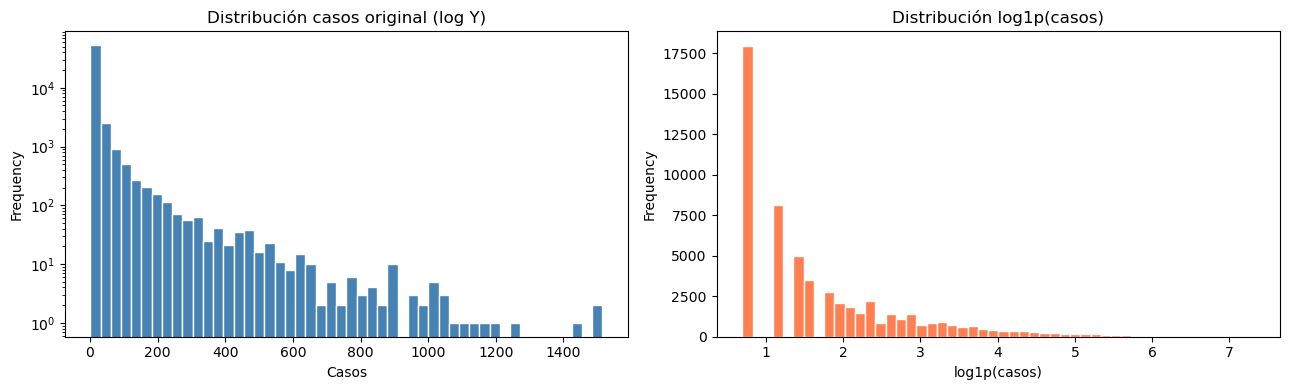

In [3]:
df['casos_log'] = np.log1p(df['casos'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['casos'][df.casos > 0].plot(
    kind='hist', bins=50, logy=True, ax=axes[0],
    color='steelblue', edgecolor='white'
)
axes[0].set(title='Distribución casos original (log Y)', xlabel='Casos')

df['casos_log'][df.casos_log > 0].plot(
    kind='hist', bins=50, ax=axes[1],
    color='coral', edgecolor='white'
)
axes[1].set(title='Distribución log1p(casos)', xlabel='log1p(casos)')
plt.tight_layout()
print('log1p aplicado ✓')

## 3. Lags autorregresivos

Calculados sobre `casos_log` para consistencia con el target transformado.

**Medias móviles:** sobre `shift(1)` para no filtrar el futuro.

In [4]:
print('Calculando lags autorregresivos...')
for lag in [1, 2, 4, 8, 12, 16, 26, 52]:
    df[f'casos_lag{lag}'] = df.groupby('ubigeo')['casos_log'].shift(lag)

# Medias móviles
df['casos_ma4']  = df.groupby('ubigeo')['casos_log'].transform(
    lambda x: x.shift(1).rolling(4,  min_periods=2).mean()
)
df['casos_ma12'] = df.groupby('ubigeo')['casos_log'].transform(
    lambda x: x.shift(1).rolling(12, min_periods=4).mean()
)

# Diferencia — captura aceleración del brote
df['casos_diff4']  = df['casos_lag1'] - df['casos_lag4']
df['casos_diff12'] = df['casos_lag1'] - df['casos_lag12']

# Lags de tasa per cápita
if 'tasa_x100k' in df.columns:
    df['tasa_lag4']  = df.groupby('ubigeo')['tasa_x100k'].shift(4)
    df['tasa_lag8']  = df.groupby('ubigeo')['tasa_x100k'].shift(8)
    df['tasa_lag12'] = df.groupby('ubigeo')['tasa_x100k'].shift(12)

print('Lags autorregresivos ✓')

Calculando lags autorregresivos...
Lags autorregresivos ✓


## 4. Lags climáticos por departamento

Cada departamento tiene su lag óptimo empírico (cross-correlation, notebook 02).
Se aplica el lag específico del departamento de cada distrito.
Para departamentos sin registro se usa la mediana nacional como fallback.

In [5]:
df_lags_opt = pd.read_csv(DATA_INTER / 'lags_optimos_departamental.csv')

lags_pivot = df_lags_opt.pivot(
    index='departamento', columns='variable', values='lag_optimo'
).round().astype(int)

# Mediana nacional por variable como fallback
lag_fallback = lags_pivot.median().round().astype(int)
print('Lags fallback (mediana nacional):')
print(lag_fallback.to_string())

vars_clima = lags_pivot.columns.tolist()

for var in vars_clima:
    if var not in df.columns:
        continue
    col_out = f'{var}_lag_depto'
    df[col_out] = np.nan

    for depto in lags_pivot.index:
        lag  = int(lags_pivot.loc[depto, var])
        mask = df['departamento'] == depto
        if mask.sum() == 0:
            continue
        df.loc[mask, col_out] = (
            df[mask]
            .groupby('ubigeo')[var]
            .transform(lambda s: s.shift(lag))
        )

    # Fallback para distritos sin departamento en el CSV
    lag_fb = int(lag_fallback[var])
    still_nan = df[col_out].isna()
    if still_nan.sum() > 0:
        df.loc[still_nan, col_out] = (
            df[still_nan]
            .groupby('ubigeo')[var]
            .transform(lambda s: s.shift(lag_fb))
        )
    print(f'  {col_out}: nulos={df[col_out].isna().mean()*100:.1f}%')

print('Lags climáticos departamentales ✓')

Lags fallback (mediana nacional):
variable
humr_clima     9
ptot_clima     9
tmean_clima    9
tmin_clima     8
  humr_clima_lag_depto: nulos=2.6%
  ptot_clima_lag_depto: nulos=1.5%
  tmean_clima_lag_depto: nulos=2.9%
  tmin_clima_lag_depto: nulos=2.6%
Lags climáticos departamentales ✓


## 5. Lags satelitales

In [6]:
LAGS_SAT = {
    'ndvi'               : 4,
    'ndwi'               : 4,
    'precip_chirps_mm'   : 4,
    'lst_day'            : 4,
    'estado_vegetacion'  : 4,
    'hum_adj_veg'        : 4,
}

for var, lag in LAGS_SAT.items():
    if var in df.columns:
        df[f'{var}_lag{lag}'] = df.groupby('ubigeo')[var].shift(lag)

print('Lags satelitales ✓')

Lags satelitales ✓


## 6. Interacciones clima × satelital

| Interacción | Señal epidemiológica |
|-------------|---------------------|
| `tmean × ndvi` | Temperatura alta + vegetación = hábitat óptimo vector |
| `ptot × ndwi` | Lluvia + agua superficial = criaderos activos |
| `humr × veg` | Humedad + vegetación = condición de reproducción |
| `chirps × ndwi` | CHIRPS + agua = criaderos confirmados |

In [7]:
if 'tmean_clima_lag_depto' in df.columns and 'ndvi_lag4' in df.columns:
    df['tmean_x_ndvi'] = df['tmean_clima_lag_depto'] * df['ndvi_lag4']
if 'ptot_clima_lag_depto' in df.columns and 'ndwi_lag4' in df.columns:
    df['ptot_x_ndwi']  = df['ptot_clima_lag_depto'] * df['ndwi_lag4']
if 'humr_clima_lag_depto' in df.columns and 'estado_vegetacion_lag4' in df.columns:
    df['humr_x_veg']   = df['humr_clima_lag_depto'] * df['estado_vegetacion_lag4']
if 'precip_chirps_mm_lag4' in df.columns and 'ndwi_lag4' in df.columns:
    df['chirps_x_ndwi']= df['precip_chirps_mm_lag4'] * df['ndwi_lag4']

print('Interacciones ✓')

Interacciones ✓


## 7. Codificación cíclica de semana epidemiológica

In [8]:
df['SE_sin'] = np.sin(2 * np.pi * df['semana_epi'] / 52)
df['SE_cos'] = np.cos(2 * np.pi * df['semana_epi'] / 52)
print('Codificación cíclica SE ✓')

Codificación cíclica SE ✓


## 8. Encoding de variables categóricas

### One-hot de `lisa_cluster`

El encoding ordinal (`cluster_code` 0-4) implica un orden que no existe
entre los tipos de cluster LISA. El one-hot elimina ese supuesto.

In [9]:
# One-hot lisa_cluster
ohe = pd.get_dummies(df['lisa_cluster'], prefix='cluster', dtype=int)
df  = pd.concat([df, ohe], axis=1)

cols_ohe = [c for c in df.columns if c.startswith('cluster_')]
print(f'One-hot columns: {cols_ohe}')
print(df[cols_ohe].sum().to_string())

One-hot columns: ['cluster_code', 'cluster_HH', 'cluster_LH', 'cluster_LL', 'cluster_ns']
cluster_code    507130
cluster_HH       55460
cluster_LH       15980
cluster_LL      253330
cluster_ns      584210


## 9. Discretización

### 9.1 Altitud — rangos epidemiológicos

| Rango | Nombre | Significado |
|-------|--------|-------------|
| 0-500m | `alt_costa` | Costa, alta transmisión |
| 500-1800m | `alt_sierra_baja` | Sierra baja, transmisión posible |
| >1800m | `alt_sierra_alta` | Límite biológico del vector |

In [10]:
if 'altitud' in df.columns:
    df['alt_zona'] = pd.cut(
        df['altitud'],
        bins=[-1, 500, 1800, 99999],
        labels=['costa_selva', 'sierra_baja', 'sierra_alta']
    )
    # One-hot de alt_zona
    ohe_alt = pd.get_dummies(df['alt_zona'], prefix='alt', dtype=int)
    df = pd.concat([df, ohe_alt], axis=1)

    print('Distribución por zona altitudinal:')
    print(df['alt_zona'].value_counts().to_string())

Distribución por zona altitudinal:
alt_zona
sierra_alta    619930
sierra_baja    189880
costa_selva     98700


### 9.2 Categorización de casos

Variable ordinal útil para PyMC y Prophet para distinguir
semanas sin transmisión, transmisión baja, media y alta.

In [11]:
df['casos_cat'] = pd.cut(
    df['casos'],
    bins=[-1, 0, 5, 20, 99999],
    labels=[0, 1, 2, 3]  # 0=cero, 1=bajo, 2=medio, 3=alto
).astype(int)

print('Distribución casos_cat:')
print(df['casos_cat'].value_counts().sort_index().to_string())

Distribución casos_cat:
casos_cat
0    850860
1     37369
2     13147
3      7604


## 10. Sample weights

Mayor peso a semanas con casos > 0 en distritos endémicos.
Penaliza menos los errores en distritos estructuralmente limpios (LL).

$$w_i = 1 + \log(1 + casos_i) \times (1 + cluster\_code_i / 4)$$

Sample weights:
count    908980.000
mean          1.000
std           0.654
min           0.874
25%           0.874
50%           0.874
75%           0.874
max          13.668


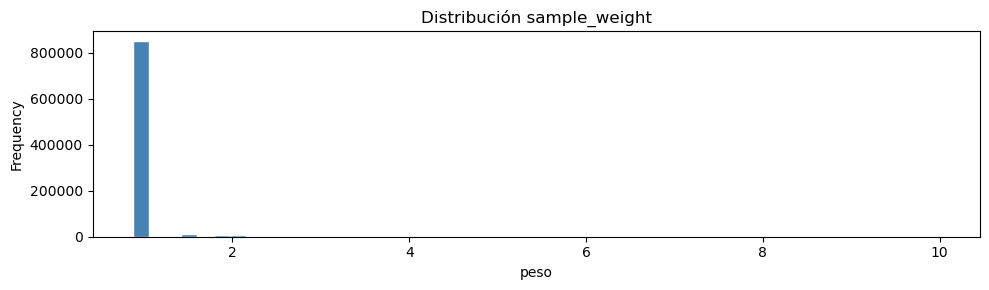

In [12]:
df['sample_weight'] = (
    1 + np.log1p(df['casos']) * (1 + df['cluster_code'] / 4)
)
# Normalizar a media=1
df['sample_weight'] = df['sample_weight'] / df['sample_weight'].mean()

print('Sample weights:')
print(df['sample_weight'].describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 3))
df['sample_weight'].clip(0, 10).plot(
    kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='white'
)
ax.set(title='Distribución sample_weight', xlabel='peso')
plt.tight_layout()

## 11. Targets por horizonte

Shift negativo — predice `horizonte` semanas hacia el futuro.
Las últimas `horizonte` semanas de cada distrito quedan como NaN.

In [13]:
for h in HORIZONTES:
    df[f'target_h{h}']     = df.groupby('ubigeo')['casos'].shift(-h)
    df[f'target_h{h}_log'] = np.log1p(
        df[f'target_h{h}'].clip(0)
    )

print('Targets:')
for h in HORIZONTES:
    n_validos = df[f'target_h{h}'].notna().sum()
    print(f'  target_h{h}: {n_validos:,} válidos '
          f'({n_validos/len(df)*100:.1f}%)')

Targets:
  target_h4: 901,416 válidos (99.2%)
  target_h8: 893,852 válidos (98.3%)
  target_h12: 886,288 válidos (97.5%)


## 12. Lista de features para los modelos

In [14]:
# Features base para todos los modelos
FEAT_AUTOREGRESIVAS = (
    [f'casos_lag{l}' for l in [1,2,4,8,12,16,26,52]] +
    ['casos_ma4','casos_ma12','casos_diff4','casos_diff12']
)

FEAT_CLIMATICAS = (
    [f'{v}_lag_depto' for v in ['humr_clima','ptot_clima','tmean_clima','tmin_clima']
     if f'{v}_lag_depto' in df.columns]
)

FEAT_SATELITALES = (
    [f'{v}_lag{l}' for v,l in [
        ('ndvi',4),('ndwi',4),('precip_chirps_mm',4),
        ('lst_day',4),('estado_vegetacion',4),('hum_adj_veg',4)
    ] if f'{v}_lag{l}' in df.columns]
)

FEAT_INTERACCIONES = [
    c for c in ['tmean_x_ndvi','ptot_x_ndwi','humr_x_veg','chirps_x_ndwi']
    if c in df.columns
]

FEAT_ESPACIALES = [
    c for c in ['endemico','cluster_code','flag_anomalia',
                'cluster_HH','cluster_LL','cluster_LH',
                'alt_costa_selva','alt_sierra_baja','alt_sierra_alta']
    if c in df.columns
]

FEAT_TOPOGRAFICAS = [c for c in ['altitud','pendiente'] if c in df.columns]

FEAT_CICLICAS = ['SE_sin','SE_cos']

FEAT_TASA = [c for c in ['tasa_lag4','tasa_lag8','tasa_lag12']
             if c in df.columns]

ALL_FEATURES = (
    FEAT_AUTOREGRESIVAS + FEAT_CLIMATICAS + FEAT_SATELITALES +
    FEAT_INTERACCIONES  + FEAT_ESPACIALES + FEAT_TOPOGRAFICAS +
    FEAT_CICLICAS       + FEAT_TASA
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f'Total features: {len(ALL_FEATURES)}')
print(f'  Autorregresivas : {len(FEAT_AUTOREGRESIVAS)}')
print(f'  Climáticas      : {len(FEAT_CLIMATICAS)}')
print(f'  Satelitales     : {len(FEAT_SATELITALES)}')
print(f'  Interacciones   : {len(FEAT_INTERACCIONES)}')
print(f'  Espaciales      : {len(FEAT_ESPACIALES)}')
print(f'  Topográficas    : {len(FEAT_TOPOGRAFICAS)}')
print(f'  Cíclicas        : {len(FEAT_CICLICAS)}')
print(f'  Tasa per cápita : {len(FEAT_TASA)}')

Total features: 41
  Autorregresivas : 12
  Climáticas      : 4
  Satelitales     : 5
  Interacciones   : 4
  Espaciales      : 9
  Topográficas    : 2
  Cíclicas        : 2
  Tasa per cápita : 3


## 13. Verificación de calidad del AMT

In [15]:
print('=== CALIDAD DEL AMT ===')
print(f'Shape: {df.shape}')
print(f'Distritos: {df.ubigeo.nunique()}')
print(f'Rango: {df.fecha.min().date()} → {df.fecha.max().date()}')

# Nulos por grupo de features
print('\nNulos por grupo:')
for nombre, cols in [
    ('Autorregresivas', FEAT_AUTOREGRESIVAS),
    ('Climáticas',      FEAT_CLIMATICAS),
    ('Satelitales',     FEAT_SATELITALES),
    ('Interacciones',   FEAT_INTERACCIONES),
    ('Espaciales',      FEAT_ESPACIALES),
]:
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok: continue
    pct = df[cols_ok].isnull().mean().mean() * 100
    print(f'  {nombre:15s}: {pct:.1f}% nulos promedio')

# Distribución de targets
print('\nDistribución targets:')
for h in HORIZONTES:
    t = df[f'target_h{h}'].dropna()
    pct_cero = (t==0).mean()*100
    print(f'  H={h:2d}: media={t.mean():.2f} | '
          f'mediana={t.median():.1f} | '
          f'%ceros={pct_cero:.1f}%')

=== CALIDAD DEL AMT ===
Shape: (908980, 84)
Distritos: 1891
Rango: 2018-01-01 → 2026-12-28

Nulos por grupo:
  Autorregresivas: 2.5% nulos promedio
  Climáticas     : 2.4% nulos promedio
  Satelitales    : 8.9% nulos promedio
  Interacciones  : 9.7% nulos promedio
  Espaciales     : 0.0% nulos promedio

Distribución targets:
  H= 4: media=0.95 | mediana=0.0 | %ceros=93.6%
  H= 8: media=0.95 | mediana=0.0 | %ceros=93.5%
  H=12: media=0.96 | mediana=0.0 | %ceros=93.5%


## 14. Guardar AMT y metadata

In [16]:
import json

# Guardar AMT
out_path = DATA_INTER / 'AMT_final.parquet'
df.to_parquet(out_path, index=False)
print(f'✓ AMT_final.parquet guardado')
print(f'  Shape : {df.shape}')
print(f'  Tamaño: {out_path.stat().st_size/1e6:.1f} MB')

# Guardar metadata de features
meta = {
    'all_features'        : ALL_FEATURES,
    'feat_autoregresivas' : FEAT_AUTOREGRESIVAS,
    'feat_climaticas'     : FEAT_CLIMATICAS,
    'feat_satelitales'    : FEAT_SATELITALES,
    'feat_interacciones'  : FEAT_INTERACCIONES,
    'feat_espaciales'     : FEAT_ESPACIALES,
    'feat_topograficas'   : FEAT_TOPOGRAFICAS,
    'feat_ciclicas'       : FEAT_CICLICAS,
    'feat_tasa'           : FEAT_TASA,
    'horizontes'          : HORIZONTES,
    'corte_train'         : '2022-12-31',
    'corte_val'           : '2023-12-31',
    'use_log'             : True,
    'n_distritos'         : int(df.ubigeo.nunique()),
    'n_filas'             : len(df),
}

meta_path = DATA_INTER / 'AMT_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'✓ AMT_metadata.json guardado')

✓ AMT_final.parquet guardado
  Shape : (908980, 84)
  Tamaño: 52.8 MB
✓ AMT_metadata.json guardado


## 15. Cómo usar el AMT en los notebooks de modelos

```python
import pandas as pd
import json
from pathlib import Path

DATA_INTER = Path('data/interim')

# Cargar AMT
df = pd.read_parquet(DATA_INTER / 'AMT_final.parquet')

# Cargar lista de features
with open(DATA_INTER / 'AMT_metadata.json') as f:
    meta = json.load(f)
FEAT_COLS = meta['all_features']

# Split temporal
CORTE_TRAIN = meta['corte_train']
CORTE_VAL   = meta['corte_val']
HORIZONTE   = 4  # o 8 o 12
TARGET      = f'target_h{HORIZONTE}_log'

data  = df.dropna(subset=[TARGET]).copy()
train = data[data.fecha <= CORTE_TRAIN]
val   = data[(data.fecha > CORTE_TRAIN) & (data.fecha <= CORTE_VAL)]
test  = data[data.fecha > CORTE_VAL]

X_tr, y_tr = train[FEAT_COLS].fillna(0), train[TARGET]
X_va, y_va = val[FEAT_COLS].fillna(0),   val[TARGET]
X_te, y_te = test[FEAT_COLS].fillna(0),  test[TARGET]
```